### Machine Learning 
- Model Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')

### Import the Data

In [2]:
%%capture
data = pd.read_csv('data/student.csv')
data.head()

In [3]:
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Prepare Features and Target
From the EDA, maths score was the subject students struggled with most and the one least correlated with reading/writing, which makes it the most interesting target to predict from the other features.

In [4]:
X = data.drop(columns=['math score'])
y = data['math score']

numeric_features = X.select_dtypes(exclude='object').columns
categorical_features = X.select_dtypes(include='object').columns

print('Numeric features:', list(numeric_features))
print('Categorical features:', list(categorical_features))

Numeric features: ['reading score', 'writing score']
Categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


### Preprocessing
- Numeric pipeline: impute missing values with the median, then scale (reading score, writing score)
- Categorical pipeline: impute missing values with the most frequent value, then one-hot encode, then scale (gender, race/ethnicity, parental level of education, lunch, test preparation course)

The imputers don't change anything on this particular dataset (no missing values), but they make the pipeline robust to missing values in future/unseen data, matching the production `data_transformation.py` component.

In [5]:
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

cat_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('one_hot_encoder', OneHotEncoder()),
        ('scaler', StandardScaler(with_mean=False))
    ]
)

preprocessor = ColumnTransformer(
    [
        ('num_pipeline', num_pipeline, numeric_features),
        ('cat_pipeline', cat_pipeline, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipeline', ...), ('cat_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` an

### Train/Test Split
Splitting before fitting the preprocessor so no information from the test set leaks into the scaling/encoding.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print('X_train shape:', X_train_transformed.shape)
print('X_test shape:', X_test_transformed.shape)

X_train shape: (800, 19)
X_test shape: (200, 19)


### Train and Compare Models
Fit each model on the training set and evaluate on the test set using RMSE, MAE, and R².

In [7]:
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2


models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'K-Neighbors Regressor': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'AdaBoost Regressor': AdaBoostRegressor(random_state=42),
    'SVR': SVR(),
    'XGBRegressor': XGBRegressor(random_state=42, verbosity=0),
    'CatBoosting Regressor': CatBoostRegressor(random_state=42, verbose=False),
}

results = []

for name, model in models.items():
    model.fit(X_train_transformed, y_train)

    y_train_pred = model.predict(X_train_transformed)
    y_test_pred = model.predict(X_test_transformed)

    train_rmse, train_mae, train_r2 = evaluate_model(y_train, y_train_pred)
    test_rmse, test_mae, test_r2 = evaluate_model(y_test, y_test_pred)

    results.append({
        'Model': name,
        'Train RMSE': train_rmse,
        'Train MAE': train_mae,
        'Train R2': train_r2,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test R2': test_r2,
    })

results_df = pd.DataFrame(results).sort_values(by='Test R2', ascending=False).reset_index(drop=True)
results_df

,Model,Train RMSE,Train MAE,Train R2,Test RMSE,Test MAE,Test R2
0,Ridge,5.323205,4.265041,0.874310,5.390973,4.212648,0.880567
1,Linear Regression,5.323051,4.266712,0.874317,5.393994,4.214763,0.880433
2,Lasso,5.903266,4.691208,0.845425,5.910591,4.628662,0.856434
3,AdaBoost Regressor,5.780344,4.730278,0.851795,6.008278,4.681343,0.851649
4,CatBoosting Regressor,3.053013,2.402360,0.958656,6.033317,4.589369,0.850410
5,Random Forest Regressor,2.303510,1.824858,0.976464,6.033663,4.701467,0.850393
6,XGBRegressor,1.007282,0.687467,0.995500,6.595750,5.103630,0.821221
7,Decision Tree,0.279508,0.018750,0.999653,7.840918,6.240000,0.747348
8,SVR,7.398065,5.640938,0.757232,8.708429,6.445140,0.688349
9,K-Neighbors Regressor,8.238185,6.564000,0.698964,11.296185,8.691000,0.475612


I found that **Ridge** and **Linear Regression** generalize best (Test R² ~0.88), edging out every tree-based and boosted model. Meanwhile Decision Tree, XGBoost, and CatBoost post near-perfect train R² (0.95-0.99) but a noticeably lower test R² a classic overfitting signature on a dataset this small (800 training rows, 19 features after encoding). With reading/writing scores as strong linear predictors of maths score, there just isn't enough non-linear signal for the more complex models to exploit, so the simpler linear models win out.

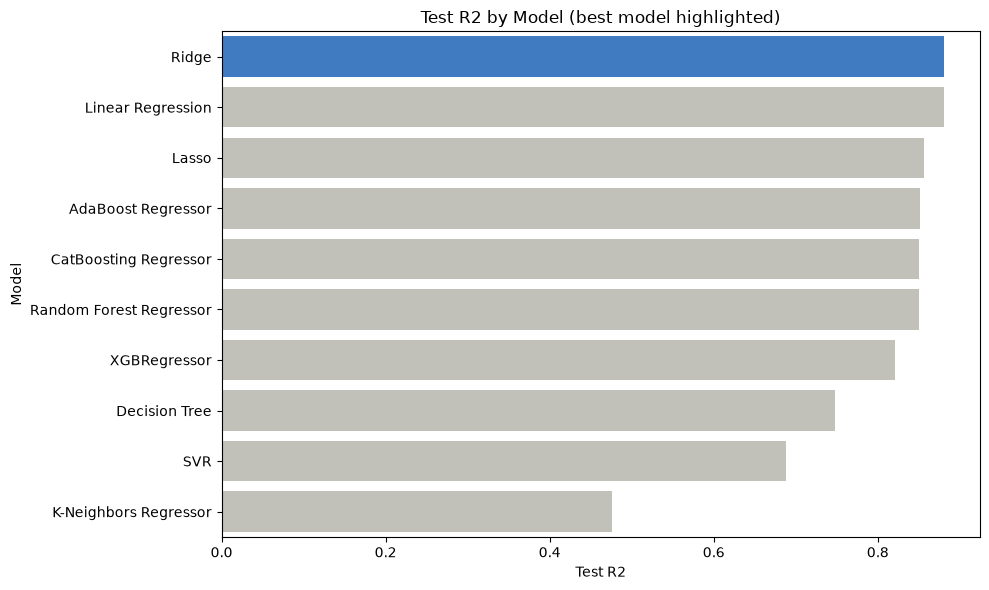

In [8]:
bar_colors = ['#2a78d6' if i == 0 else '#c3c2b7' for i in range(len(results_df))]

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Test R2', y='Model', hue='Model', palette=bar_colors, legend=False)
plt.title('Test R2 by Model (best model highlighted)')
plt.xlabel('Test R2')
plt.tight_layout()
plt.savefig('images/model_comparison_r2.png')
plt.show()

### Best Model: Ridge Regression


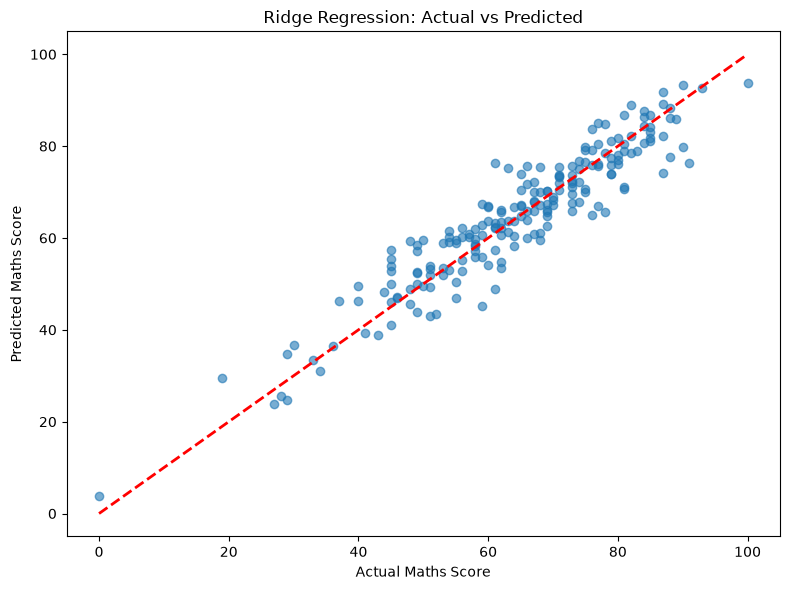

In [9]:
best_model = Ridge()
best_model.fit(X_train_transformed, y_train)
y_test_pred = best_model.predict(X_test_transformed)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Maths Score')
plt.ylabel('Predicted Maths Score')
plt.title('Ridge Regression: Actual vs Predicted')
plt.tight_layout()
plt.savefig('images/ridge_actual_vs_predicted.png')
plt.show()

### Residuals
Plotting the actual score against the residual (actual − predicted). Points should scatter randomly around the 0 line with no pattern — a trend or funnel shape would signal the model is systematically off in some region of the score range.

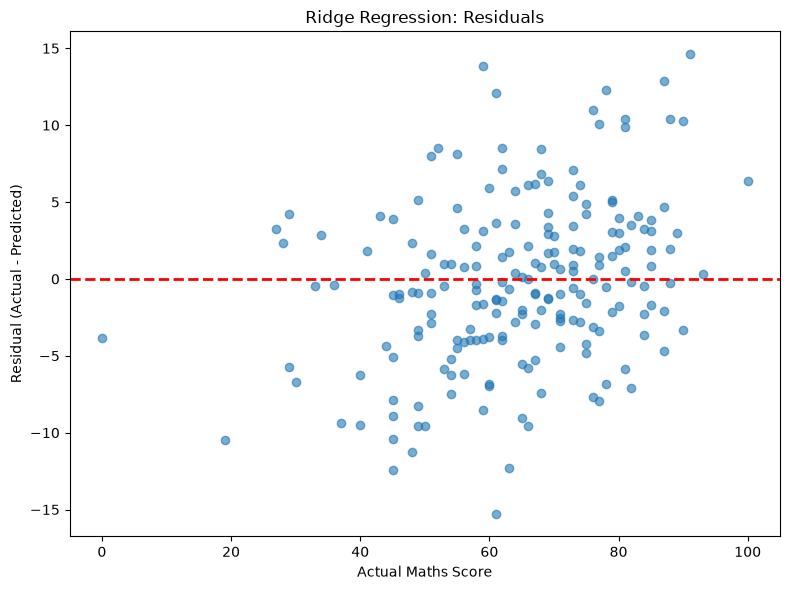

In [10]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_test, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.xlabel('Actual Maths Score')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Ridge Regression: Residuals')
plt.tight_layout()
plt.savefig('images/ridge_residuals.png')
plt.show()

In [11]:
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred,
    'Difference': residuals
})
comparison_df.head(20)

,Actual,Predicted,Difference
521,91,76.390277,14.609723
737,53,58.832701,-5.832701
740,80,76.995321,3.004679
660,74,76.826110,-2.826110
411,84,87.654028,-3.654028
678,81,78.936807,2.063193
626,69,64.705783,4.294217
513,54,53.027455,0.972545
859,87,74.134834,12.865166
136,51,49.350461,1.649539


## Conclusion

- **Ridge Regression** is the best-performing model for predicting maths score, explaining ~88% of the variance on unseen data (Test R² = 0.880, RMSE ≈ 5.4 points), and it does so with far less overfitting than the tree-based/boosted alternatives.
- Reading and writing scores, combined with lunch type, test preparation course, and parental education, carry enough linear signal that the added complexity of Random Forest, XGBoost, and CatBoost doesn't pay off on a dataset this size — they overfit the training set instead.
- Plain Linear Regression performs almost identically to Ridge, suggesting the regularization isn't doing much heavy lifting here — the relationship between the features and maths score is close to linear to begin with.
- **Next steps**: this could be extended with hyperparameter tuning (e.g. `RandomizedSearchCV` on Ridge's `alpha`) or by gathering more training data to see if the boosted models start to pull ahead once they have more examples to learn from.